In [149]:
from records import get_clean_data, get_constructs_data, CONSTRUCTS
from sklearn.linear_model import LinearRegression
from factor_analyzer import FactorAnalyzer
from pyprocessmacro import Process
from itertools import combinations
import matplotlib.pyplot as plt
import pingouin as pg
import seaborn as sns
import pandas as pd
import numpy as np
import semopy

In [150]:
import warnings
warnings.filterwarnings("ignore")

In [151]:
df = get_clean_data(file_path="../data/extract_2026_05_16.xlsx")
constructs_df = get_constructs_data(df)

In [152]:
CONSTRUCTS

{'perceived_information_reliance_on_llm': ['perceived_information_reliance_on_llm_a',
  'perceived_information_reliance_on_llm_b',
  'perceived_information_reliance_on_llm_c'],
 'perceived_trustworthiness_among_teams': ['perceived_trustworthiness_among_teams_a',
  'perceived_trustworthiness_among_teams_b',
  'perceived_trustworthiness_among_teams_d'],
 'perceived_team_performance': ['perceived_team_performance_a',
  'perceived_team_performance_b',
  'perceived_team_performance_c']}

In [153]:
constructs_df.info()

<class 'pandas.DataFrame'>
Index: 138 entries, 3 to 142
Data columns (total 10 columns):
 #   Column                                   Non-Null Count  Dtype
---  ------                                   --------------  -----
 0   perceived_information_reliance_on_llm_a  138 non-null    int64
 1   perceived_information_reliance_on_llm_b  138 non-null    int64
 2   perceived_information_reliance_on_llm_c  138 non-null    int64
 3   perceived_trustworthiness_among_teams_a  138 non-null    int64
 4   perceived_trustworthiness_among_teams_b  138 non-null    int64
 5   perceived_trustworthiness_among_teams_c  138 non-null    int64
 6   perceived_trustworthiness_among_teams_d  138 non-null    int64
 7   perceived_team_performance_a             138 non-null    int64
 8   perceived_team_performance_b             138 non-null    int64
 9   perceived_team_performance_c             138 non-null    int64
dtypes: int64(10)
memory usage: 11.9 KB


# Internal Consistency Reliability

## Cronbach's Alpha

In [154]:
for construct, items in CONSTRUCTS.items():
    alpha, _ = pg.cronbach_alpha(data=constructs_df[items])
    print(f"{construct:<45} {alpha:>12.4f} {len(items):>8}")

perceived_information_reliance_on_llm               0.6832        3
perceived_trustworthiness_among_teams               0.7668        3
perceived_team_performance                          0.8511        3


## Confirmatory Factor Analysis (CFA)

In [155]:
items = [
    'perceived_information_reliance_on_llm_a',
    'perceived_information_reliance_on_llm_b',
    'perceived_information_reliance_on_llm_c',
    'perceived_trustworthiness_among_teams_a',
    'perceived_trustworthiness_among_teams_b',
    'perceived_trustworthiness_among_teams_c',
    'perceived_trustworthiness_among_teams_d',
    'perceived_team_performance_a',
    'perceived_team_performance_b',
    'perceived_team_performance_c'
]

fa = FactorAnalyzer(n_factors=3, rotation='varimax')
fa.fit(constructs_df[items])

loadings_matrix = pd.DataFrame(
    fa.loadings_,
    index=items,
    columns=['Factor_1', 'Factor_2', 'Factor_3']
)
loadings_matrix['Highest_Factor'] = loadings_matrix.idxmax(axis=1)

In [156]:
loadings_matrix

,Factor_1,Factor_2,Factor_3,Highest_Factor
perceived_information_reliance_on_llm_a,0.027452,0.367047,0.175370,Factor_2
perceived_information_reliance_on_llm_b,0.045855,0.963702,-0.056613,Factor_2
perceived_information_reliance_on_llm_c,-0.184356,0.688898,-0.115304,Factor_2
perceived_trustworthiness_among_teams_a,0.619257,0.024730,-0.228843,Factor_1
perceived_trustworthiness_among_teams_b,0.788916,-0.069118,0.064017,Factor_1
perceived_trustworthiness_among_teams_c,0.061999,0.018922,0.594766,Factor_3
perceived_trustworthiness_among_teams_d,0.723874,-0.036563,0.199264,Factor_1
perceived_team_performance_a,0.799483,-0.028373,0.085694,Factor_1
perceived_team_performance_b,0.813724,-0.027670,0.151138,Factor_1
perceived_team_performance_c,0.771573,-0.054642,-0.019461,Factor_1


### remove perceived_trustworthiness_among_teams_c

In [157]:
items = [
    'perceived_information_reliance_on_llm_a',
    'perceived_information_reliance_on_llm_b',
    'perceived_information_reliance_on_llm_c',
    'perceived_trustworthiness_among_teams_a',
    'perceived_trustworthiness_among_teams_b',
    'perceived_trustworthiness_among_teams_d',
    'perceived_team_performance_a',
    'perceived_team_performance_b',
    'perceived_team_performance_c'
]

fa = FactorAnalyzer(n_factors=3, rotation='varimax')
fa.fit(constructs_df[items])

loadings_matrix = pd.DataFrame(
    fa.loadings_,
    index=items,
    columns=['Factor_1', 'Factor_2', 'Factor_3']
)
loadings_matrix['Highest_Factor'] = loadings_matrix.idxmax(axis=1)

In [158]:
loadings_matrix

,Factor_1,Factor_2,Factor_3,Highest_Factor
perceived_information_reliance_on_llm_a,0.019826,0.375080,0.183117,Factor_2
perceived_information_reliance_on_llm_b,0.040754,0.917060,-0.003394,Factor_2
perceived_information_reliance_on_llm_c,-0.163377,0.729572,-0.248109,Factor_2
perceived_trustworthiness_among_teams_a,0.614694,0.023793,-0.144767,Factor_1
perceived_trustworthiness_among_teams_b,0.827936,-0.085637,-0.136463,Factor_1
perceived_trustworthiness_among_teams_d,0.723723,-0.047317,0.059210,Factor_1
perceived_team_performance_a,0.786021,-0.022672,0.195865,Factor_1
perceived_team_performance_b,0.804901,-0.012070,0.372926,Factor_1
perceived_team_performance_c,0.757265,-0.050201,0.090827,Factor_1


In [159]:
# removed perceived_trustworthiness_among_teams_c +
model_desc = """
perceived_information_reliance_on_llm =~ perceived_information_reliance_on_llm_a + perceived_information_reliance_on_llm_b + perceived_information_reliance_on_llm_c
perceived_trustworthiness_among_teams =~ perceived_trustworthiness_among_teams_a + perceived_trustworthiness_among_teams_b + perceived_trustworthiness_among_teams_d
perceived_team_performance =~ perceived_team_performance_a + perceived_team_performance_b + perceived_team_performance_c
"""

model = semopy.Model(model_desc)
model.fit(constructs_df)

# Get standardized loadings
inspected = model.inspect(mode='list', what='est', std_est=True)
loadings = inspected[inspected['op'] == '~']

In [160]:
stats = semopy.calc_stats(model)
results = model.inspect()
print(results)

                                       lval  op  \
0   perceived_information_reliance_on_llm_a   ~   
1   perceived_information_reliance_on_llm_b   ~   
2   perceived_information_reliance_on_llm_c   ~   
3   perceived_trustworthiness_among_teams_a   ~   
4   perceived_trustworthiness_among_teams_b   ~   
5   perceived_trustworthiness_among_teams_d   ~   
6              perceived_team_performance_a   ~   
7              perceived_team_performance_b   ~   
8              perceived_team_performance_c   ~   
9     perceived_information_reliance_on_llm  ~~   
10               perceived_team_performance  ~~   
11               perceived_team_performance  ~~   
12               perceived_team_performance  ~~   
13    perceived_trustworthiness_among_teams  ~~   
14    perceived_trustworthiness_among_teams  ~~   
15  perceived_information_reliance_on_llm_a  ~~   
16  perceived_information_reliance_on_llm_b  ~~   
17  perceived_information_reliance_on_llm_c  ~~   
18             perceived_team_p

In [161]:
stats

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,24,36,29.852666,0.189683,544.355214,0.988487,0.94516,0.917739,0.94516,0.982731,0.04219,41.567353,103.03968,0.216324


Confirmatory factor analysis was conducted to assess the measurement model fit. Results indicated good to excellent fit across all indices: χ²(24) = 29.85, p = .190, CFI = 0.988, TLI = 0.983, NFI = 0.945, GFI = 0.945, AGFI = 0.918, RMSEA = 0.042. These values collectively exceed conventional thresholds for good model fit, supporting the validity of the proposed factor structure.

## Composite Reliability

In [162]:
def compute_CR(x):
    sum_lam = np.sum(x)
    sum_delta = np.sum(1 - x**2)
    return sum_lam**2 / (sum_lam**2 + sum_delta)
cr = (loadings.groupby('rval')['Est. Std']
      .apply(compute_CR))
print("CR:\n", cr)

CR:
 rval
perceived_information_reliance_on_llm    0.736481
perceived_team_performance               0.854818
perceived_trustworthiness_among_teams    0.772632
Name: Est. Std, dtype: float64


## Cronbach's alpha & CR

In [163]:
for construct, items in CONSTRUCTS.items():
    # Cronbach's alpha
    alpha, _ = pg.cronbach_alpha(data=constructs_df[items])
    
    # CR
    cr = compute_CR(loadings[loadings['rval'] == construct]['Est. Std'].values)
    
    print(f"{construct:<45} {alpha:>12.4f} {cr:>8.4f} {len(items):>8}")

perceived_information_reliance_on_llm               0.6832   0.7365        3
perceived_trustworthiness_among_teams               0.7668   0.7726        3
perceived_team_performance                          0.8511   0.8548        3


- 0.6 to 0.7 is acceptable for exploratory research
- above 0.9 or below 0.6 is concidered a lack of internal consistency reliability

# Convergent validity

## Outer loadings

In [164]:
# Calculate mean and std for each construct
desc_stats = constructs_df.agg(['mean', 'std']).T
desc_stats.columns = ['Mean', 'Std Dev']

# Merge with loadings
loadings_with_stats = loadings[['lval', 'rval', 'Est. Std']].copy()
loadings_with_stats = loadings_with_stats.merge(desc_stats, left_on='lval', right_index=True)

print(loadings_with_stats)

                                      lval  \
0  perceived_information_reliance_on_llm_a   
1  perceived_information_reliance_on_llm_b   
2  perceived_information_reliance_on_llm_c   
3  perceived_trustworthiness_among_teams_a   
4  perceived_trustworthiness_among_teams_b   
5  perceived_trustworthiness_among_teams_d   
6             perceived_team_performance_a   
7             perceived_team_performance_b   
8             perceived_team_performance_c   

                                    rval  Est. Std      Mean   Std Dev  
0  perceived_information_reliance_on_llm  0.344904  3.949275  0.757661  
1  perceived_information_reliance_on_llm  1.000000  3.847826  0.836243  
2  perceived_information_reliance_on_llm  0.662603  3.826087  0.887159  
3  perceived_trustworthiness_among_teams  0.603955  3.608696  0.840879  
4  perceived_trustworthiness_among_teams  0.821674  3.239130  0.985696  
5  perceived_trustworthiness_among_teams  0.751678  3.471014  0.864482  
6             perceived_team

In [165]:
# item - construct - loading
print("Outer Loadings:\n", loadings[['lval', 'rval', 'Est. Std']])
loadings


Outer Loadings:
                                       lval  \
0  perceived_information_reliance_on_llm_a   
1  perceived_information_reliance_on_llm_b   
2  perceived_information_reliance_on_llm_c   
3  perceived_trustworthiness_among_teams_a   
4  perceived_trustworthiness_among_teams_b   
5  perceived_trustworthiness_among_teams_d   
6             perceived_team_performance_a   
7             perceived_team_performance_b   
8             perceived_team_performance_c   

                                    rval  Est. Std  
0  perceived_information_reliance_on_llm  0.344904  
1  perceived_information_reliance_on_llm  1.000000  
2  perceived_information_reliance_on_llm  0.662603  
3  perceived_trustworthiness_among_teams  0.603955  
4  perceived_trustworthiness_among_teams  0.821674  
5  perceived_trustworthiness_among_teams  0.751678  
6             perceived_team_performance  0.816407  
7             perceived_team_performance  0.841683  
8             perceived_team_performance  0.7

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,perceived_information_reliance_on_llm_a,~,perceived_information_reliance_on_llm,1.000000,0.344904,-,-,-
1,perceived_information_reliance_on_llm_b,~,perceived_information_reliance_on_llm,3.200117,1.000000,1.114783,2.870619,0.004097
2,perceived_information_reliance_on_llm_c,~,perceived_information_reliance_on_llm,2.249537,0.662603,0.564302,3.986404,0.000067
3,perceived_trustworthiness_among_teams_a,~,perceived_trustworthiness_among_teams,1.000000,0.603955,-,-,-
4,perceived_trustworthiness_among_teams_b,~,perceived_trustworthiness_among_teams,1.594658,0.821674,0.223684,7.129065,0.0
5,perceived_trustworthiness_among_teams_d,~,perceived_trustworthiness_among_teams,1.279387,0.751678,0.189001,6.769221,0.0
6,perceived_team_performance_a,~,perceived_team_performance,1.000000,0.816407,-,-,-
7,perceived_team_performance_b,~,perceived_team_performance,0.922129,0.841683,0.084377,10.928696,0.0
8,perceived_team_performance_c,~,perceived_team_performance,0.914413,0.782959,0.091363,10.008531,0.0


outer loadings 
- below 0.4 and above 0.95 should be removed :
    - perceived_trustworthiness_among_teams_c (0.125998)
    - perceived_information_reliance_on_llm_a (0.344917)
    - perceived_information_reliance_on_llm (1.000)

- between 0.4 and 0.7 should be deleted if it increases CR, to check : 
    - perceived_information_reliance_on_llm_c (0.662610)
    - perceived_trustworthiness_among_teams_a (0.600193)




In [166]:
# outer loadings between 0.4 and 0.7 should be deleted if it increases CR
model_desc = """
perceived_information_reliance_on_llm =~ perceived_information_reliance_on_llm_a + perceived_information_reliance_on_llm_b + perceived_information_reliance_on_llm_c
perceived_trustworthiness_among_teams =~ perceived_trustworthiness_among_teams_a + perceived_trustworthiness_among_teams_b + perceived_trustworthiness_among_teams_c + perceived_trustworthiness_among_teams_d
perceived_team_performance =~ perceived_team_performance_a + perceived_team_performance_b + perceived_team_performance_c
"""

model = semopy.Model(model_desc)
model.fit(constructs_df)

# Get standardized loadings
inspected = model.inspect(mode='list', what='est', std_est=True)
loadings = inspected[inspected['op'] == '~']

def compute_CR(x):
    sum_lam = np.sum(x)
    sum_delta = np.sum(1 - x**2)
    return sum_lam**2 / (sum_lam**2 + sum_delta)
cr = (loadings.groupby('rval')['Est. Std']
      .apply(compute_CR))
print("CR:\n", cr)

CR:
 rval
perceived_information_reliance_on_llm    0.736487
perceived_team_performance               0.854839
perceived_trustworthiness_among_teams    0.690603
Name: Est. Std, dtype: float64


In [167]:
print(constructs_df[['perceived_information_reliance_on_llm_a',
            'perceived_information_reliance_on_llm_b',
            'perceived_information_reliance_on_llm_c']].corr())

                                         perceived_information_reliance_on_llm_a  \
perceived_information_reliance_on_llm_a                                 1.000000   
perceived_information_reliance_on_llm_b                                 0.344864   
perceived_information_reliance_on_llm_c                                 0.225685   

                                         perceived_information_reliance_on_llm_b  \
perceived_information_reliance_on_llm_a                                 0.344864   
perceived_information_reliance_on_llm_b                                 1.000000   
perceived_information_reliance_on_llm_c                                 0.662627   

                                         perceived_information_reliance_on_llm_c  
perceived_information_reliance_on_llm_a                                 0.225685  
perceived_information_reliance_on_llm_b                                 0.662627  
perceived_information_reliance_on_llm_c                                 1.000

- a ↔ b = 0.345 --> weak
- a ↔ c = 0.226 --> very weak
- b ↔ c = 0.663 --> acceptable

### perceived_information_reliance_on_llm : drop a

In [168]:
model_desc = """
perceived_information_reliance_on_llm =~ perceived_information_reliance_on_llm_a + perceived_information_reliance_on_llm_b + perceived_information_reliance_on_llm_c
perceived_trustworthiness_among_teams =~ perceived_trustworthiness_among_teams_a + perceived_trustworthiness_among_teams_b + perceived_trustworthiness_among_teams_c + perceived_trustworthiness_among_teams_d
perceived_team_performance =~ perceived_team_performance_a + perceived_team_performance_b + perceived_team_performance_c
"""

model = semopy.Model(model_desc)
model.fit(constructs_df)

# Get standardized loadings
inspected = model.inspect(mode='list', what='est', std_est=True)
loadings = inspected[inspected['op'] == '~']

def compute_CR(x):
    sum_lam = np.sum(x)
    sum_delta = np.sum(1 - x**2)
    return sum_lam**2 / (sum_lam**2 + sum_delta)
cr = (loadings.groupby('rval')['Est. Std']
      .apply(compute_CR))
print("CR:\n", cr)

CR:
 rval
perceived_information_reliance_on_llm    0.736487
perceived_team_performance               0.854839
perceived_trustworthiness_among_teams    0.690603
Name: Est. Std, dtype: float64


In [169]:
# item - construct - loading
print("Outer Loadings:\n", loadings[['lval', 'rval', 'Est. Std']])

Outer Loadings:
                                       lval  \
0  perceived_information_reliance_on_llm_a   
1  perceived_information_reliance_on_llm_b   
2  perceived_information_reliance_on_llm_c   
3  perceived_trustworthiness_among_teams_a   
4  perceived_trustworthiness_among_teams_b   
5  perceived_trustworthiness_among_teams_c   
6  perceived_trustworthiness_among_teams_d   
7             perceived_team_performance_a   
8             perceived_team_performance_b   
9             perceived_team_performance_c   

                                    rval  Est. Std  
0  perceived_information_reliance_on_llm  0.344917  
1  perceived_information_reliance_on_llm  1.000000  
2  perceived_information_reliance_on_llm  0.662610  
3  perceived_trustworthiness_among_teams  0.600193  
4  perceived_trustworthiness_among_teams  0.822746  
5  perceived_trustworthiness_among_teams  0.125998  
6  perceived_trustworthiness_among_teams  0.754683  
7             perceived_team_performance  0.816091  

- when i drop a , cr increase from 0.73 to 0.83 but c becomes 1.0 in outerloading 
- when i drop b, cr decrease to 0.61 but a becomes 1.0 in outerloading 
- when i drop c, cr decrease to 0.62 and outer loading becomes 0.92 for a and 0.37 for b

#### Composite score

##### perceived_information_reliance_on_llm

In [170]:
df_composite = constructs_df.copy()
df_composite['perceived_information_reliance_on_llm'] = df_composite[
    ['perceived_information_reliance_on_llm_a',
     'perceived_information_reliance_on_llm_b',
     'perceived_information_reliance_on_llm_c']
].mean(axis=1)

In [171]:
alpha, _ = pg.cronbach_alpha(data=df_composite[
    ['perceived_information_reliance_on_llm_a',
     'perceived_information_reliance_on_llm_b',
     'perceived_information_reliance_on_llm_c']
])
print(f"Cronbach's alpha (perceived_information_reliance_on_llm): {alpha:.4f}")


Cronbach's alpha (perceived_information_reliance_on_llm): 0.6832


_i dont know if i should remove a (0.34 the lowest) or b (1.0 the highest) so i'm gna leave it for now_

##### perceived_trustworthiness_among_teams

In [172]:
df_composite['perceived_trustworthiness_among_teams'] = df_composite[
    ['perceived_trustworthiness_among_teams_a',
     'perceived_trustworthiness_among_teams_b',
     'perceived_trustworthiness_among_teams_d']
].mean(axis=1)

In [173]:
alpha, _ = pg.cronbach_alpha(data=df_composite[
    ['perceived_trustworthiness_among_teams_a',
     'perceived_trustworthiness_among_teams_b',
     'perceived_trustworthiness_among_teams_d']
])
print(f"Cronbach's alpha (perceived_trustworthiness_among_teams): {alpha:.4f}")

Cronbach's alpha (perceived_trustworthiness_among_teams): 0.7668


#### perceived_team_performance

In [174]:
df_composite["perceived_team_performance"] = df_composite[
    ['perceived_team_performance_a',
        'perceived_team_performance_b',
        'perceived_team_performance_c']
].mean(axis=1)

In [175]:
alpha, _ = pg.cronbach_alpha(data=df_composite[
    ['perceived_trustworthiness_among_teams_a',
     'perceived_trustworthiness_among_teams_b',
     'perceived_trustworthiness_among_teams_d']
])
print(f"Cronbach's alpha (perceived_trustworthiness_among_teams): {alpha:.4f}")

Cronbach's alpha (perceived_trustworthiness_among_teams): 0.7668


### perceived_information_reliance_on_llm

In [176]:
df_composite["perceived_information_reliance_on_llm"] = df_composite[
    ['perceived_information_reliance_on_llm_a',
        'perceived_information_reliance_on_llm_b',
        'perceived_information_reliance_on_llm_c']
].mean(axis=1)

In [177]:
alpha, _ = pg.cronbach_alpha(data=df_composite[
    ['perceived_information_reliance_on_llm_a',
     'perceived_information_reliance_on_llm_b',
     'perceived_information_reliance_on_llm_c']
])
print(f"Cronbach's alpha (perceived_information_reliance_on_llm): {alpha:.4f}")

Cronbach's alpha (perceived_information_reliance_on_llm): 0.6832


### perceived_trustworthiness_among_teams : drop c

In [178]:
model_desc = """
perceived_trustworthiness_among_teams =~ perceived_trustworthiness_among_teams_a + perceived_trustworthiness_among_teams_b + perceived_trustworthiness_among_teams_d
perceived_information_reliance_on_llm =~ perceived_information_reliance_on_llm_a + perceived_information_reliance_on_llm_b + perceived_information_reliance_on_llm_c
perceived_team_performance =~ perceived_team_performance_a + perceived_team_performance_b + perceived_team_performance_c
"""

model = semopy.Model(model_desc)
model.fit(constructs_df)

# Get standardized loadings
inspected = model.inspect(mode='list', what='est', std_est=True)
loadings = inspected[inspected['op'] == '~']

def compute_CR(x):
    sum_lam = np.sum(x)
    sum_delta = np.sum(1 - x**2)
    return sum_lam**2 / (sum_lam**2 + sum_delta)
cr = (loadings.groupby('rval')['Est. Std']
      .apply(compute_CR))
print("CR:\n", cr)

CR:
 rval
perceived_information_reliance_on_llm    0.736481
perceived_team_performance               0.854818
perceived_trustworthiness_among_teams    0.772632
Name: Est. Std, dtype: float64


In [179]:
print("Outer Loadings:\n", loadings[['lval', 'rval', 'Est. Std']])

Outer Loadings:
                                       lval  \
0  perceived_trustworthiness_among_teams_a   
1  perceived_trustworthiness_among_teams_b   
2  perceived_trustworthiness_among_teams_d   
3  perceived_information_reliance_on_llm_a   
4  perceived_information_reliance_on_llm_b   
5  perceived_information_reliance_on_llm_c   
6             perceived_team_performance_a   
7             perceived_team_performance_b   
8             perceived_team_performance_c   

                                    rval  Est. Std  
0  perceived_trustworthiness_among_teams  0.603955  
1  perceived_trustworthiness_among_teams  0.821674  
2  perceived_trustworthiness_among_teams  0.751678  
3  perceived_information_reliance_on_llm  0.344904  
4  perceived_information_reliance_on_llm  1.000000  
5  perceived_information_reliance_on_llm  0.662603  
6             perceived_team_performance  0.816407  
7             perceived_team_performance  0.841683  
8             perceived_team_performance  0.7

- after removing perceived_trustworthiness_among_teams_c (0.125), cr decrease slightly from 0.854839 to 0.854818 --> it's okay 
- then we removed perceived_trustworthiness_among_teams_a (0.603955), cr decrease also slightly from 0.854818 to 0.854694 (decided to not remove it)


- ** ONLY perceived_trustworthiness_among_teams_*c* was removed at this stage **


## Average variance extraction (AVE)

In [180]:
ave = (loadings.groupby('rval')['Est. Std']
       .apply(lambda x: np.sum(x**2) / len(x)))
print("AVE:\n", ave)

AVE:
 rval
perceived_information_reliance_on_llm    0.519334
perceived_team_performance               0.662658
perceived_trustworthiness_among_teams    0.534977
Name: Est. Std, dtype: float64


In [181]:
# check CR
cr = (loadings.groupby('rval')['Est. Std']
      .apply(compute_CR))
print("CR:\n", cr)


CR:
 rval
perceived_information_reliance_on_llm    0.736481
perceived_team_performance               0.854818
perceived_trustworthiness_among_teams    0.772632
Name: Est. Std, dtype: float64


# Discriminent validity

## Cross loadings (EFA)

In [182]:
items = [
    'perceived_information_reliance_on_llm_a',
    'perceived_information_reliance_on_llm_b',
    'perceived_information_reliance_on_llm_c',
    'perceived_trustworthiness_among_teams_a',
    'perceived_trustworthiness_among_teams_b',
    'perceived_trustworthiness_among_teams_d',
    'perceived_team_performance_a',
    'perceived_team_performance_b',
    'perceived_team_performance_c'
]

fa = FactorAnalyzer(n_factors=3, rotation='varimax')
fa.fit(constructs_df[items])

loadings_matrix = pd.DataFrame(
    fa.loadings_,
    index=items,
    columns=['Factor_1', 'Factor_2', 'Factor_3']
)
loadings_matrix['Highest_Factor'] = loadings_matrix.idxmax(axis=1)


In [183]:
print(loadings_matrix)

                                         Factor_1  Factor_2  Factor_3  \
perceived_information_reliance_on_llm_a  0.019826  0.375080  0.183117   
perceived_information_reliance_on_llm_b  0.040754  0.917060 -0.003394   
perceived_information_reliance_on_llm_c -0.163377  0.729572 -0.248109   
perceived_trustworthiness_among_teams_a  0.614694  0.023793 -0.144767   
perceived_trustworthiness_among_teams_b  0.827936 -0.085637 -0.136463   
perceived_trustworthiness_among_teams_d  0.723723 -0.047317  0.059210   
perceived_team_performance_a             0.786021 -0.022672  0.195865   
perceived_team_performance_b             0.804901 -0.012070  0.372926   
perceived_team_performance_c             0.757265 -0.050201  0.090827   

                                        Highest_Factor  
perceived_information_reliance_on_llm_a       Factor_2  
perceived_information_reliance_on_llm_b       Factor_2  
perceived_information_reliance_on_llm_c       Factor_2  
perceived_trustworthiness_among_teams_a  

In [184]:
loadings_matrix

,Factor_1,Factor_2,Factor_3,Highest_Factor
perceived_information_reliance_on_llm_a,0.019826,0.375080,0.183117,Factor_2
perceived_information_reliance_on_llm_b,0.040754,0.917060,-0.003394,Factor_2
perceived_information_reliance_on_llm_c,-0.163377,0.729572,-0.248109,Factor_2
perceived_trustworthiness_among_teams_a,0.614694,0.023793,-0.144767,Factor_1
perceived_trustworthiness_among_teams_b,0.827936,-0.085637,-0.136463,Factor_1
perceived_trustworthiness_among_teams_d,0.723723,-0.047317,0.059210,Factor_1
perceived_team_performance_a,0.786021,-0.022672,0.195865,Factor_1
perceived_team_performance_b,0.804901,-0.012070,0.372926,Factor_1
perceived_team_performance_c,0.757265,-0.050201,0.090827,Factor_1


- !Problem

perceived_team_performance_a         -    perceived_trustworthiness_among_teams  
perceived_team_performance_b         -               perceived_team_performance  
perceived_team_performance_c         -    perceived_trustworthiness_among_teams  

## Fornell-Larcker criterion

In [185]:
ave = (loadings.groupby('rval')['Est. Std']
       .apply(lambda x: np.sum(x**2) / len(x)))
print("AVE:\n", ave)

AVE:
 rval
perceived_information_reliance_on_llm    0.519334
perceived_team_performance               0.662658
perceived_trustworthiness_among_teams    0.534977
Name: Est. Std, dtype: float64


In [186]:
# Correlation between latent constructs
constructs_items = {
    'perceived_trustworthiness_among_teams': [
        'perceived_trustworthiness_among_teams_a',
        'perceived_trustworthiness_among_teams_b',
        'perceived_trustworthiness_among_teams_d'
    ],
    'perceived_team_performance': [
        'perceived_team_performance_a',
        'perceived_team_performance_b',
        'perceived_team_performance_c'
    ]
}

# Composite scores for correlation
for construct, items in constructs_items.items():
    constructs_df[construct] = constructs_df[items].mean(axis=1)

corr = constructs_df[list(constructs_items.keys())].corr()

# Fornell-Larcker matrix
fl = corr.copy()
for construct in constructs_items.keys():
    fl.loc[construct, construct] = np.sqrt(ave[construct])

print(fl.round(3))

                                       perceived_trustworthiness_among_teams  \
perceived_trustworthiness_among_teams                                  0.731   
perceived_team_performance                                             0.758   

                                       perceived_team_performance  
perceived_trustworthiness_among_teams                       0.758  
perceived_team_performance                                  0.814  


- ! Problem

perceived_trustworthiness_among_teams fails the Fornell-Larcker criterion : its square root of AVE (0.731) is lower than its correlation with perceived_team_performance (0.758). This means the two constructs are not sufficiently distinct from each other.

## HTMT

In [187]:
items_per_construct = {
    'perceived_information_reliance_on_llm': [
        'perceived_information_reliance_on_llm_a',
        'perceived_information_reliance_on_llm_b',
        'perceived_information_reliance_on_llm_c'
    ],
    'perceived_trustworthiness_among_teams': [
        'perceived_trustworthiness_among_teams_a',
        'perceived_trustworthiness_among_teams_b',
        'perceived_trustworthiness_among_teams_d'
    ],
    'perceived_team_performance': [
        'perceived_team_performance_a',
        'perceived_team_performance_b',
        'perceived_team_performance_c'
    ]
}

constructs = list(items_per_construct.keys())
for c1, c2 in combinations(constructs, 2):
    items1 = items_per_construct[c1]
    items2 = items_per_construct[c2]
    
    # Average heterotrait-heteromethod correlations
    hetero_corrs = []
    for i in items1:
        for j in items2:
            hetero_corrs.append(constructs_df[i].corr(constructs_df[j]))
    
    # Average monotrait correlations for each construct
    mono_corrs1 = [constructs_df[i].corr(constructs_df[j]) for i, j in combinations(items1, 2)]
    mono_corrs2 = [constructs_df[i].corr(constructs_df[j]) for i, j in combinations(items2, 2)]
    
    htmt = np.mean(hetero_corrs) / np.sqrt(np.mean(mono_corrs1) * np.mean(mono_corrs2))
    
    print(f"HTMT ({c1} <-> {c2}): {htmt:.4f}")

HTMT (perceived_information_reliance_on_llm <-> perceived_trustworthiness_among_teams): -0.1016
HTMT (perceived_information_reliance_on_llm <-> perceived_team_performance): -0.0994
HTMT (perceived_trustworthiness_among_teams <-> perceived_team_performance): 0.9325


HTMT of 0.933 is well above the 0.85 threshold : meaning the two constructs are not sufficiently distinct from each other. This is consistent with:

- Fornell-Larcker failure (0.731 < 0.758)
- Cross loading issues with perceived_team_performance_a and perceived_team_performance_c

In [188]:
# Define model with all three constructs
# IR is included but we will compute its HTMT manually
# since it has estimation issues as a latent variable

# First compute HTMT between TT and TP using CFA
model_spec_tt_tp = """
perceived_trustworthiness_among_teams =~ perceived_trustworthiness_among_teams_a + perceived_trustworthiness_among_teams_b + perceived_trustworthiness_among_teams_d
perceived_team_performance =~ perceived_team_performance_a + perceived_team_performance_b + perceived_team_performance_c
"""

# HTMT formula for composite IR
# HTMT = mean of all cross-construct correlations / 
#         sqrt(mean within-construct correlations product)

def compute_htmt_composite(df, construct1_items, construct2_items):
    """
    Compute HTMT between a latent construct and a composite
    using the correlation-based formula
    """
    # Cross construct correlations
    cross_corrs = []
    for item1 in construct1_items:
        for item2 in construct2_items:
            cross_corrs.append(df[item1].corr(df[item2]))
    
    # Within construct 1 correlations
    within1_corrs = []
    for i, item1 in enumerate(construct1_items):
        for item2 in construct1_items[i+1:]:
            within1_corrs.append(df[item1].corr(df[item2]))
    
    # Within construct 2 correlations
    within2_corrs = []
    for i, item1 in enumerate(construct2_items):
        for item2 in construct2_items[i+1:]:
            within2_corrs.append(df[item1].corr(df[item2]))
    
    mean_cross = np.mean(cross_corrs)
    mean_within1 = np.mean(within1_corrs)
    mean_within2 = np.mean(within2_corrs)
    
    htmt = mean_cross / np.sqrt(mean_within1 * mean_within2)
    return htmt

# Define items
tt_items = ['perceived_trustworthiness_among_teams_a',
            'perceived_trustworthiness_among_teams_b',
            'perceived_trustworthiness_among_teams_d']

tp_items = ['perceived_team_performance_a',
            'perceived_team_performance_b',
            'perceived_team_performance_c']

ir_items = ['perceived_information_reliance_on_llm_a',
            'perceived_information_reliance_on_llm_b',
            'perceived_information_reliance_on_llm_c']

# Compute original HTMT values
original_htmt_tt_tp = compute_htmt_composite(constructs_df, tt_items, tp_items)
original_htmt_tt_ir = compute_htmt_composite(constructs_df, tt_items, ir_items)
original_htmt_tp_ir = compute_htmt_composite(constructs_df, tp_items, ir_items)

print(f"Original HTMT TT <-> TP: {round(original_htmt_tt_tp, 4)}")
print(f"Original HTMT TT <-> IR: {round(original_htmt_tt_ir, 4)}")
print(f"Original HTMT TP <-> IR: {round(original_htmt_tp_ir, 4)}")

# Bootstrap all three HTMT values
n_bootstrap = 10000
bootstrap_tt_tp = []
bootstrap_tt_ir = []
bootstrap_tp_ir = []

np.random.seed(42)

for i in range(n_bootstrap):
    # Resample with replacement
    boot_sample = constructs_df.sample(
        n=len(constructs_df),
        replace=True
    ).reset_index(drop=True)
    
    try:
        htmt_tt_tp = compute_htmt_composite(boot_sample, tt_items, tp_items)
        htmt_tt_ir = compute_htmt_composite(boot_sample, tt_items, ir_items)
        htmt_tp_ir = compute_htmt_composite(boot_sample, tp_items, ir_items)
        
        if 0 < htmt_tt_tp < 2:
            bootstrap_tt_tp.append(htmt_tt_tp)
        if 0 < htmt_tt_ir < 2:
            bootstrap_tt_ir.append(htmt_tt_ir)
        if 0 < htmt_tp_ir < 2:
            bootstrap_tp_ir.append(htmt_tp_ir)
            
    except:
        continue

# Convert to arrays
bootstrap_tt_tp = np.array(bootstrap_tt_tp)
bootstrap_tt_ir = np.array(bootstrap_tt_ir)
bootstrap_tp_ir = np.array(bootstrap_tp_ir)

# Calculate statistics for each pair
def htmt_stats(original, bootstrap_vals):
    return {
        'Original Sample': round(original, 4),
        'Sample Mean': round(np.mean(bootstrap_vals), 4),
        'Bias': round(np.mean(bootstrap_vals) - original, 4),
        '2.5%': round(np.percentile(bootstrap_vals, 2.5), 4),
        '97.5%': round(np.percentile(bootstrap_vals, 97.5), 4)
    }

results = pd.DataFrame([
    htmt_stats(original_htmt_tt_tp, bootstrap_tt_tp),
    htmt_stats(original_htmt_tt_ir, bootstrap_tt_ir),
    htmt_stats(original_htmt_tp_ir, bootstrap_tp_ir)
], index=[
    'TT <-> TP',
    'TT <-> IR',
    'TP <-> IR'
])

print("\nHTMT Bootstrap Results:")
print(results)

Original HTMT TT <-> TP: 0.9325
Original HTMT TT <-> IR: -0.1016
Original HTMT TP <-> IR: -0.0994

HTMT Bootstrap Results:
           Original Sample  Sample Mean    Bias    2.5%   97.5%
TT <-> TP           0.9325       0.9335  0.0010  0.8471  1.0108
TT <-> IR          -0.1016       0.0733  0.1749  0.0018  0.2339
TP <-> IR          -0.0994       0.0636  0.1630  0.0018  0.2033


## Multicollinearity

In [189]:
constructs_df['perceived_information_reliance_on_llm'] = constructs_df[
    ['perceived_information_reliance_on_llm_a',
     'perceived_information_reliance_on_llm_b',
     'perceived_information_reliance_on_llm_c']
].mean(axis=1)
constructs_df['perceived_team_performance'] = constructs_df[
    ['perceived_team_performance_a',
    'perceived_team_performance_b',
    'perceived_team_performance_c']
].mean(axis=1)
constructs_df['perceived_trustworthiness_among_teams'] = constructs_df[
    ['perceived_trustworthiness_among_teams_a',
     'perceived_trustworthiness_among_teams_b',
     'perceived_trustworthiness_among_teams_d']
].mean(axis=1)  

In [190]:
items = [
    'perceived_team_performance',
    'perceived_information_reliance_on_llm',
    'perceived_trustworthiness_among_teams'
]

vif_data = []

for item in items:
    X = constructs_df[[i for i in items if i != item]]
    y = constructs_df[item]

    r2 = LinearRegression().fit(X, y).score(X, y)
    tol = 1 - r2
    vif = 1 / tol
    
    vif_data.append({'Item': item, 'Tolerance': round(tol, 4), 'VIF': round(vif, 4)})

vif_df = pd.DataFrame(vif_data)
print(vif_df)

                                    Item  Tolerance     VIF
0             perceived_team_performance     0.4247  2.3547
1  perceived_information_reliance_on_llm     0.9924  1.0077
2  perceived_trustworthiness_among_teams     0.4249  2.3532


# MODEL

In [191]:
df.columns

Index(['StartDate', 'EndDate', 'Status', 'IPAddress', 'Progress',
       'Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId',
       'RecipientLastName', 'RecipientFirstName', 'RecipientEmail',
       'ExternalReference', 'LocationLatitude', 'LocationLongitude',
       'DistributionChannel', 'UserLanguage', 'Q_RecaptchaScore',
       'perceived_information_reliance_on_llm_a',
       'perceived_information_reliance_on_llm_b',
       'perceived_information_reliance_on_llm_c',
       'perceived_trustworthiness_among_teams_a',
       'perceived_trustworthiness_among_teams_b',
       'perceived_trustworthiness_among_teams_c',
       'perceived_trustworthiness_among_teams_d',
       'perceived_team_performance_a', 'perceived_team_performance_b',
       'perceived_team_performance_c', 'age_range', 'academic_level',
       'frequency_group_assignments', 'definition_llm', 'definition_llm_text',
       'academic_field', 'academic_field_text',
       'frequency_llm_usage_assignments

In [192]:
df_model = df.copy()

In [193]:
df_model['perceived_information_reliance_on_llm'] = df_model[
    ['perceived_information_reliance_on_llm_a',
     'perceived_information_reliance_on_llm_b',
     'perceived_information_reliance_on_llm_c']
].mean(axis=1)
df_model['perceived_trustworthiness_among_teams'] = df_model[
    ['perceived_trustworthiness_among_teams_a',
     'perceived_trustworthiness_among_teams_b',
     'perceived_trustworthiness_among_teams_d']
].mean(axis=1)
df_model["perceived_team_performance"] = df_model[
    ['perceived_team_performance_a',
        'perceived_team_performance_b',
        'perceived_team_performance_c']
].mean(axis=1)

In [194]:
df_constructs = df_model[['perceived_information_reliance_on_llm', 'perceived_trustworthiness_among_teams', 'perceived_team_performance', 'age_range', 'academic_level', 'academic_field', 'frequency_llm_usage_assignments','frequency_group_assignments']].copy()

<Axes: >

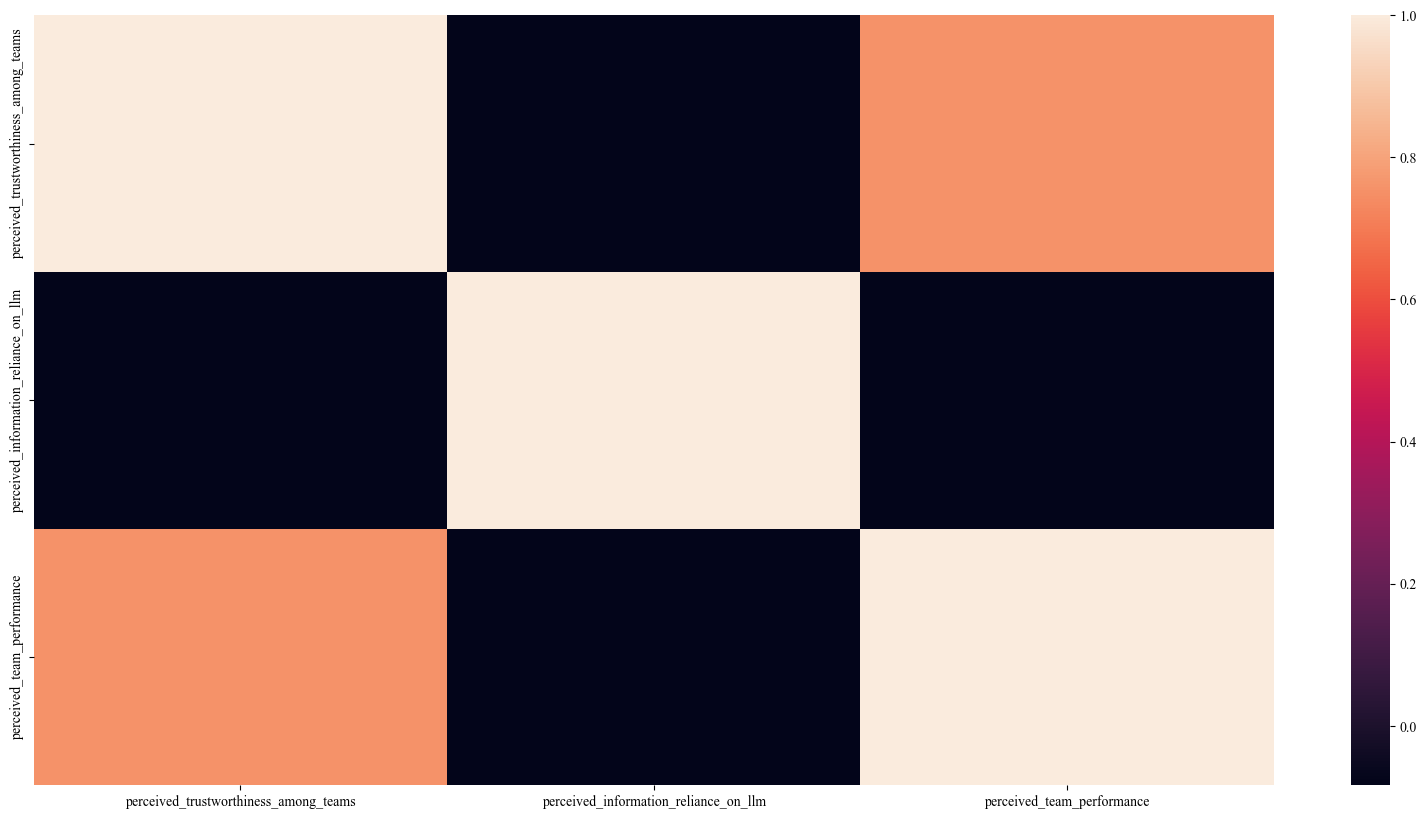

In [195]:
plt.figure(figsize=(20,10))
c=df_constructs[['perceived_trustworthiness_among_teams','perceived_information_reliance_on_llm','perceived_team_performance' ]].corr()
sns.heatmap(c)

In [196]:
def boxplot(df, column):
    sns.boxplot(data=df,x=df[f"{column}"])
    plt.title(f"Boxplot of {column}")
    plt.show()

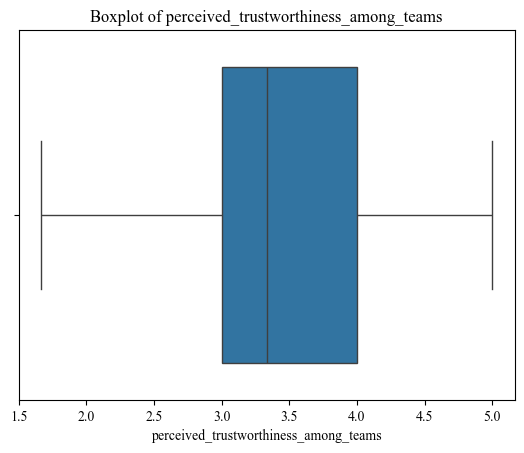

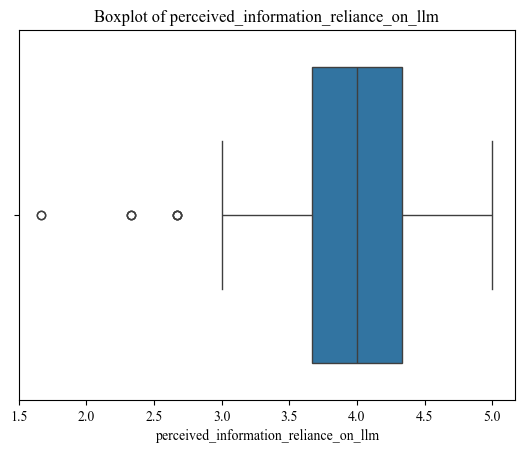

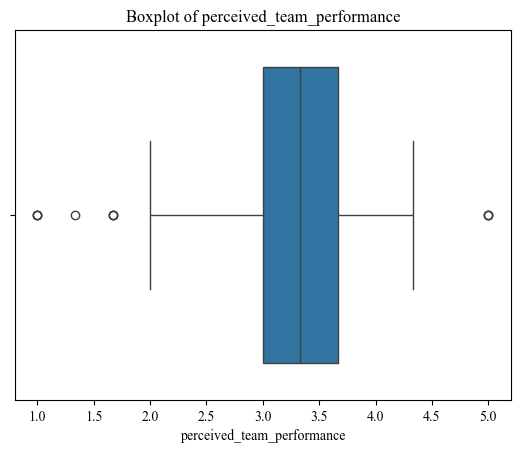

In [197]:
boxplot(df_constructs,'perceived_trustworthiness_among_teams')
boxplot(df_constructs,'perceived_information_reliance_on_llm')
boxplot(df_constructs,'perceived_team_performance')

In [198]:
df_filtered = df_constructs[(df_constructs['perceived_information_reliance_on_llm']>=2.9)&(df_constructs['perceived_team_performance']>1.7) & (df_constructs['perceived_team_performance']<4.9)].copy()

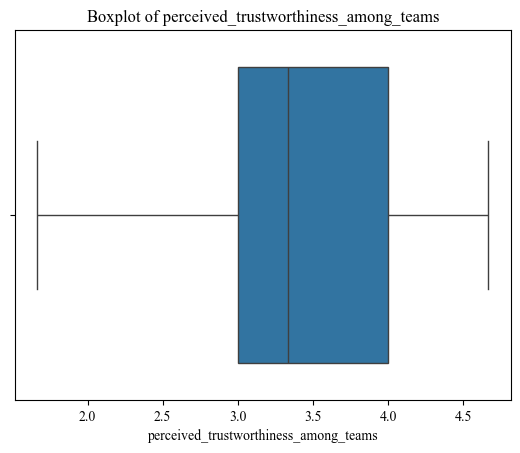

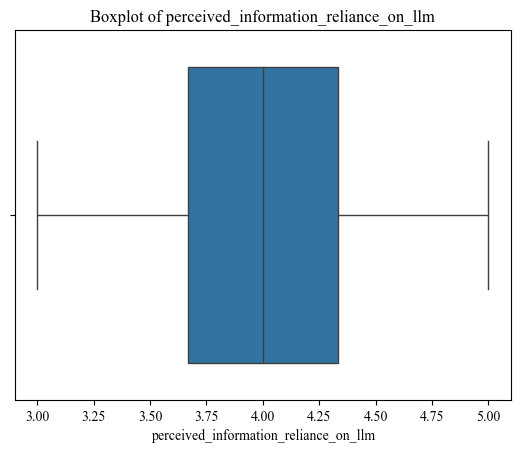

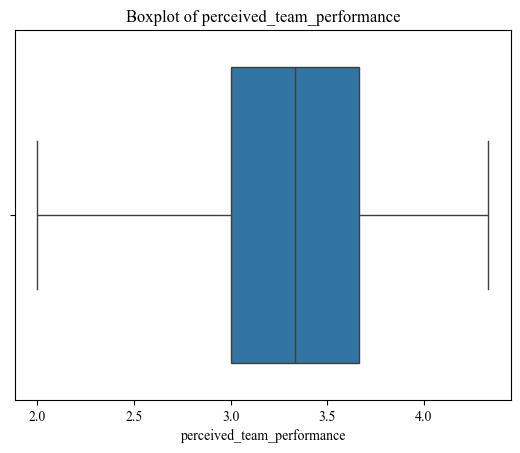

In [199]:
boxplot(df_filtered,'perceived_trustworthiness_among_teams')
boxplot(df_filtered,'perceived_information_reliance_on_llm')
boxplot(df_filtered,'perceived_team_performance')

In [200]:
df_filtered.describe()

,perceived_information_reliance_on_llm,perceived_trustworthiness_among_teams,perceived_team_performance
count,120.000000,120.000000,120.000000
mean,3.961111,3.455556,3.277778
std,0.507982,0.673541,0.625229
min,3.000000,1.666667,2.000000
25%,3.666667,3.000000,3.000000
50%,4.000000,3.333333,3.333333
75%,4.333333,4.000000,3.666667
max,5.000000,4.666667,4.333333


## WITH CONTROL

In [201]:
df_filtered.columns

Index(['perceived_information_reliance_on_llm',
       'perceived_trustworthiness_among_teams', 'perceived_team_performance',
       'age_range', 'academic_level', 'academic_field',
       'frequency_llm_usage_assignments', 'frequency_group_assignments'],
      dtype='str')

In [202]:
df_filtered['academic_field'].describe()

count     120
unique      5
top         1
freq       50
Name: academic_field, dtype: int64

In [203]:
df_filtered.describe()

,perceived_information_reliance_on_llm,perceived_trustworthiness_among_teams,perceived_team_performance
count,120.000000,120.000000,120.000000
mean,3.961111,3.455556,3.277778
std,0.507982,0.673541,0.625229
min,3.000000,1.666667,2.000000
25%,3.666667,3.000000,3.000000
50%,4.000000,3.333333,3.333333
75%,4.333333,4.000000,3.666667
max,5.000000,4.666667,4.333333


controls are  : 
- age range
- academic_level
- academic_field
- frequency_llm_usage_assignments
- frequency_group_assignments

In [204]:
p = Process(data=df_filtered, model=1, x="perceived_trustworthiness_among_teams", y="perceived_team_performance", m=["perceived_information_reliance_on_llm"],controls=['age_range', 'academic_level', 'academic_field','frequency_llm_usage_assignments'], center=True, boot=10000)
p.summary()

Process successfully initialized.
Based on the Process Macro by Andrew F. Hayes, Ph.D. (www.afhayes.com)


****************************** SPECIFICATION ****************************

Model = 1

Variables:
    Cons = Cons
    x = perceived_trustworthiness_among_teams
    y = perceived_team_performance
    m = perceived_information_reliance_on_llm
Statistical Controls:
 age_range, academic_level, academic_field, frequency_llm_usage_assignments


Mean-centered variables:
 perceived_information_reliance_on_llm, perceived_trustworthiness_among_teams



Sample size:
120

***************************** OUTCOME MODELS ****************************

Outcome = perceived_team_performance 
OLS Regression Summary

     R²  Adj. R²    MSE       F  df1  df2  p-value
 0.4824   0.4451 0.2150 14.9119    7  112   0.0000

Coefficients

                                                                              coeff     se       t      p    LLCI    ULCI
Cons                                                 

### Effect (GRAPH)

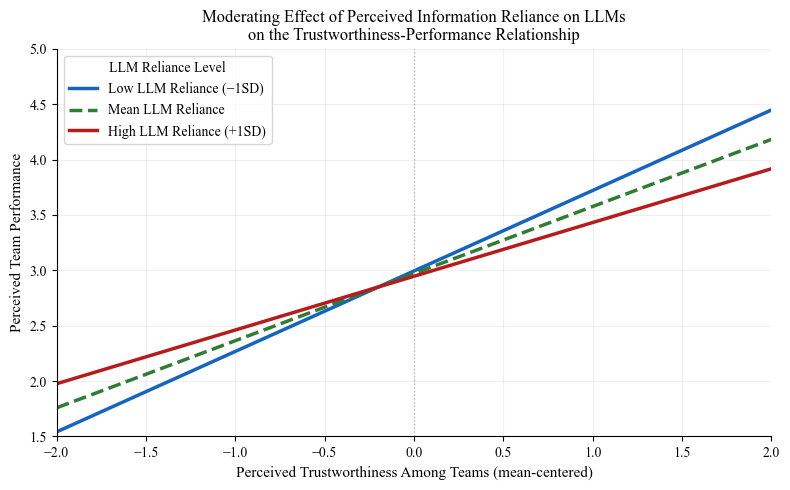

In [205]:
# Regression coefficients
b0 = 2.9704
b1 = 0.6056
b2 = -0.0473
b3 = -0.2375

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
# Moderator levels
ir_levels = {
    'Low LLM Reliance (−1SD)': -0.508,
    'Mean LLM Reliance': 0.000,
    'High LLM Reliance (+1SD)': 0.508
}

# TT range
tt_values = np.linspace(-2, 2, 100)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#1565C0', '#2E7D32', '#B71C1C']
linestyles = ['-', '--', '-']
linewidths = [2.5, 2.5, 2.5]

for (label, ir_val), color, ls, lw in zip(
    ir_levels.items(), colors, linestyles, linewidths):
    tp_pred = (b0 + b1 * tt_values + 
               b2 * ir_val + b3 * tt_values * ir_val)
    ax.plot(tt_values, tp_pred, 
            label=label, color=color,
            linestyle=ls, linewidth=lw)

# Reference line at x=0
ax.axvline(x=0, color='gray', linestyle=':', 
           linewidth=1, alpha=0.5)

# Labels
ax.set_xlabel(
    'Perceived Trustworthiness Among Teams (mean-centered)',
    fontsize=11)
ax.set_ylabel('Perceived Team Performance', fontsize=11)
ax.set_title(
    'Moderating Effect of Perceived Information Reliance on LLMs\n'
    'on the Trustworthiness-Performance Relationship',
    fontsize=12)
ax.legend(title='LLM Reliance Level', 
          fontsize=10, title_fontsize=10,
          loc='upper left')

# Clean style
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Axis limits
ax.set_xlim(-2, 2)
ax.set_ylim(1.5, 5)

plt.tight_layout()
plt.savefig('slope_plot_final.png', dpi=300, bbox_inches='tight')
plt.show()